In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Methodology and Model Selection

- Lasso is selected because it handles multicollinearity and performs feature selection by shrinking weak coefficients toward zero.
- Date is engineered into numeric calendar features (Year and Month) so scaling and linear models can consume it.
- The model is tuned with time-series cross-validation to improve generalization.

In [25]:
df = pd.read_csv('data/combined_monthly.csv')
y = df['SP500']
X = df.drop(columns=['SP500'])

# Convert date into numeric calendar features for modeling
X['Date'] = pd.to_datetime(X['Date'])
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X = X.drop(columns=['Date'])

feature_names = X.columns.tolist()

In [18]:
X.head()

,Crude_Oil,US_10Y_Yield,Copper,Steel_PPI,CPI,Unemployment_Rate,Year,Month
0,92.190002,3.378,4.4510,220.4,221.187,9.1,2011,1
1,96.970001,3.414,4.4780,239.8,221.898,9.0,2011,2
2,106.720001,3.454,4.3000,248.1,223.046,9.0,2011,3
3,113.930000,3.296,4.1655,257.3,224.093,9.1,2011,4
4,95.419998,3.158,4.2720,250.3,224.806,9.1,2011,6


In [19]:
y

0      1286.119995
1      1327.219971
2      1325.829956
3      1363.609985
4      1320.640015
          ...     
133    4845.649902
134    5096.270020
135    5254.350098
136    5035.689941
137    5277.509766
Name: SP500, Length: 138, dtype: float64

In [26]:
# Time-aware split: earlier months for training, later months for testing
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Tune Lasso with time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'alpha': np.logspace(-4, 1, 40)}
lasso_search = GridSearchCV(
    estimator=Lasso(max_iter=20000, random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv
 )
lasso_search.fit(X_train, y_train)

lasso = lasso_search.best_estimator_
print(f"Best alpha: {lasso_search.best_params_['alpha']:.6f}")
print(f"Best CV RMSE: {np.sqrt(-lasso_search.best_score_):.4f}")

Best alpha: 7.443803
Best CV RMSE: 420.2190


In [28]:
# Lasso predictions and evaluation metrics
y_pred_lasso = lasso.predict(X_test)

lasso_metrics = {
    'MSE': mean_squared_error(y_test, y_pred_lasso),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    'MAE': mean_absolute_error(y_test, y_pred_lasso),
    'R2': r2_score(y_test, y_pred_lasso)
}

print(pd.Series(lasso_metrics).round(4))

MSE     335158.5270
RMSE       578.9288
MAE        499.7064
R2          -0.7196
dtype: float64


Top 10 absolute coefficients:
Year                 509.198628
CPI                  254.121415
Steel_PPI            101.080739
Copper                83.901292
Month                 28.830290
Crude_Oil             -0.000000
US_10Y_Yield          -0.000000
Unemployment_Rate     -0.000000
dtype: float64


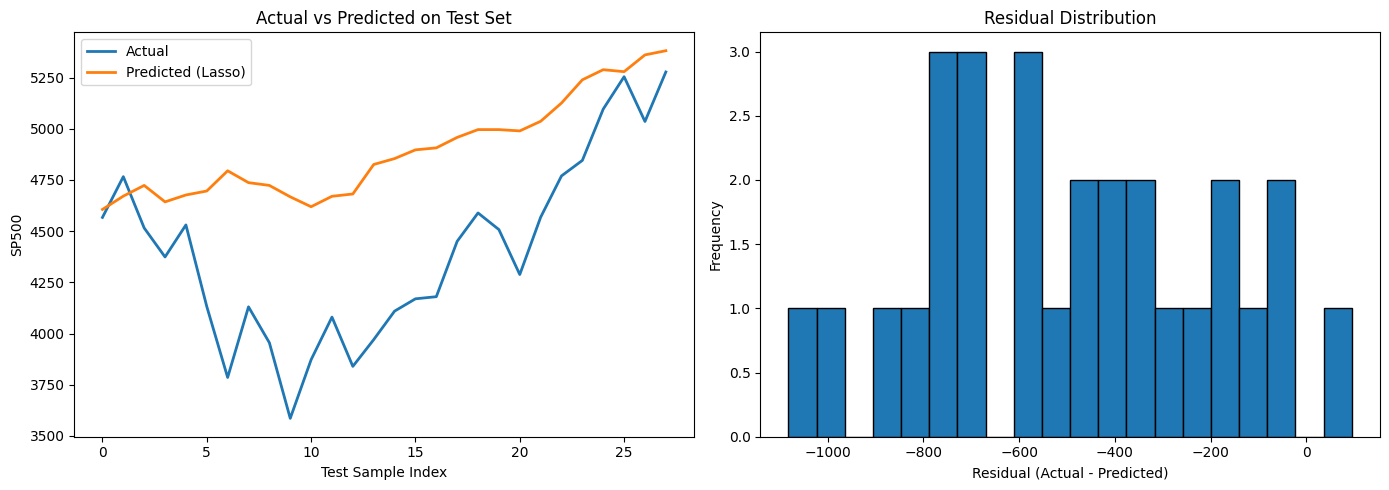

In [29]:
# Coefficient analysis (feature importance proxy in linear models)
coefficients = pd.Series(lasso.coef_, index=feature_names).sort_values(key=np.abs, ascending=False)
print('Top 10 absolute coefficients:')
print(coefficients.head(10))

# Diagnostic plots: actual vs predicted and residuals
residuals = y_test - y_pred_lasso

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(y_test.values, label='Actual', linewidth=2)
axes[0].plot(y_pred_lasso, label='Predicted (Lasso)', linewidth=2)
axes[0].set_title('Actual vs Predicted on Test Set')
axes[0].set_xlabel('Test Sample Index')
axes[0].set_ylabel('SP500')
axes[0].legend()

axes[1].hist(residuals, bins=20, edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Experimental Design, Results, and Limitations

- Data split is time-aware (first 80% train, last 20% test) to reduce temporal leakage.
- Hyperparameter tuning uses TimeSeriesSplit cross-validation and selects alpha by minimizing CV MSE.
- Results are reported with MSE, RMSE, MAE, and R2, then diagnosed with prediction and residual plots.
- Limitations: this is still a linear model, so it may miss nonlinear effects and regime changes in markets.